In [1]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [17]:
# 차트 데이터 로드
con = duckdb.connect(database='D:/Assets/BinanceFuturesData/binancefuturesdata.duckdb', read_only=True)
# BTCUSDT 2022년1월~ 2025년11월의 1분봉 데이터
data_query = "SELECT epoch_ms(timestamp) as time, open, high, low, close, volume FROM quote " \
"WHERE symbol = 'ADAUSDT' " \
"and epoch_ms(timestamp) >= '2022-01-01 00:00:00' " \
"and epoch_ms(timestamp) < '2025-12-01 00:00:00' " \
"ORDER BY timestamp;"
df = con.execute(data_query).fetchdf()
con.close()

# 1분봉 데이터 크기
print(df.shape)

# 'time' 컬럼을 Datetime 인덱스로 설정
df.set_index('time', inplace=True)
# 리샘플링 딕셔너리 정의 (OHLCV 규칙)
resample_rules = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
# 5분봉으로 리샘플링 (5T = 5 Minutes)
df = df.resample('15min', origin='start').agg(resample_rules)
# 리샘플링 과정에서 거래가 없었던 시간대(공백)는 NaN이 됩니다.
# 트레이딩 데이터에서는 이를 이전 값으로 채우거나(ffill) 제거할 수 있습니다.
# (여기서는 비정상적인 데이터이므로 제거하는 것이 일반적이나, 편의상 NaN을 가진 행을 제거합니다)
df.dropna(inplace=True)
# 인덱스(시간)를 다시 컬럼으로 변환
df.reset_index(inplace=True)

# 변환 후 크기
print(df.shape)

(2059200, 6)
(137280, 6)


In [18]:
def add_indicators(df):
    df = df.copy()
    # 1분봉이므로 노이즈가 많아 짧은/긴 이동평균선 추가
    df['ma_7'] = df['close'].rolling(window=7).mean()
    df['ma_25'] = df['close'].rolling(window=25).mean()
    df['ma_99'] = df['close'].rolling(window=99).mean()
    
    # RSI 계산
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # 볼린저 밴드 (변동성 지표)
    df['std'] = df['close'].rolling(window=20).std()
    df['upper_band'] = df['ma_25'] + (df['std'] * 2)
    df['lower_band'] = df['ma_25'] - (df['std'] * 2)
    
    # 거래량 변화율
    df['vol_change'] = df['volume'].pct_change()

    df.dropna(inplace=True) # 지표 계산으로 생긴 NaN 제거
    return df

# 지표 추가
df = add_indicators(df)
df[-5:]

,time,open,high,low,close,volume,ma_7,ma_25,ma_99,rsi,std,upper_band,lower_band,vol_change
137275,2025-11-30 22:45:00,0.4229,0.4246,0.4219,0.4241,1575345.0,0.423743,0.424128,0.419914,50.000000,0.000879,0.425885,0.422371,-0.529301
137276,2025-11-30 23:00:00,0.4242,0.4243,0.4210,0.4217,4676483.0,0.423529,0.423984,0.419989,41.139241,0.001024,0.426032,0.421936,1.968545
137277,2025-11-30 23:15:00,0.4218,0.4219,0.4184,0.4184,16546834.0,0.422843,0.423800,0.420015,32.978723,0.001601,0.427003,0.420597,2.538307
137278,2025-11-30 23:30:00,0.4184,0.4189,0.4168,0.4176,11111701.0,0.422014,0.423560,0.420040,26.373626,0.002090,0.427741,0.419379,-0.328470
137279,2025-11-30 23:45:00,0.4176,0.4181,0.4138,0.4139,10659144.0,0.420400,0.423096,0.420043,25.130890,0.002920,0.428935,0.417257,-0.040728


In [30]:
# ---------------------------------------------------------
# 분류 라벨링
# ---------------------------------------------------------

# 라벨 정의 함수
def get_class(ret):
    if ret > THRESHOLD:
        return 1  # Buy (Long)
    elif ret < -THRESHOLD:
        return 2  # Sell (Short)
    else:
        return 0  # Hold (No Action)
    
LOOK_AHEAD = 12     # 12봉 뒤 가격 예측
THRESHOLD = 0.02   # 0.5% 변동성 기준

df['future_ret'] = df['close'].shift(-LOOK_AHEAD) / df['close'] - 1
df['label'] = df['future_ret'].apply(get_class)
# 라벨링을 위해 사용한 future_ret 컬럼과 마지막 LOOK_AHEAD 만큼의 데이터(정답 없음) 제거
df.dropna(subset=['future_ret'], inplace=True)
# 클래스 분포 확인 (불균형 체크)
df['label'].value_counts()

label
0    118052
2      9582
1      9497
Name: count, dtype: int64

In [31]:
# 무한대(inf)를 NaN으로 변환
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# NaN이 포함된 행 제거
df.dropna(inplace=True)
# 남은 행 개수
df.shape

(137131, 16)

In [32]:
# ---------------------------------------------------------
# 데이터 정규화
# ---------------------------------------------------------
# 입력 피처 선택 (시간 제외, 미래 참조 데이터 제외)
feature_cols = ['open', 'high', 'low', 'close', 'volume', 'ma_7', 'ma_25', 'ma_99', 'rsi', 'upper_band', 'lower_band', 'vol_change']
target_col = 'label'
# Train/Test 분리 (시계열 순서 유지)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]
# 스케일링 (StandardScaler 권장 - 이상치에 조금 더 강함)
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_df[feature_cols])
test_X_scaled = scaler.transform(test_df[feature_cols])
# 타겟은 스케일링 하지 않음 (0, 1, 2 정수이므로)
train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

# 시퀀스 생성 함수
def create_dataset(X, y, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps]) # 시퀀스 끝나는 시점의 라벨
    return np.array(Xs), np.array(ys)

TIME_STEPS = 18 # 과거 18봉 데이터를 보고 판단

X_train, y_train_int = create_dataset(train_X_scaled, train_y_raw, TIME_STEPS)
X_test, y_test_int = create_dataset(test_X_scaled, test_y_raw, TIME_STEPS)

# ---------------------------------------------------------
# One-Hot Encoding (분류 모델 필수)
# 0 -> [1, 0, 0], 1 -> [0, 1, 0], 2 -> [0, 0, 1]
# ---------------------------------------------------------
y_train = to_categorical(y_train_int, num_classes=3)
y_test = to_categorical(y_test_int, num_classes=3)

# 전처리 결과 출력
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (109686, 18, 12)
y_train: (109686, 3)
X_test: (27409, 18, 12)


In [33]:
# 클래스 불균형이 심해서 클래스 가중치 계산해서 변수에 저장하는 단계가 필요

# ---------------------------------------------------------
# 클래스 가중치 계산 (Class Weight Calculation)
# 목적: 데이터가 적은 Buy(1)/Sell(2) 클래스에 더 큰 중요도를 부여하여
#      모델이 "무조건 Hold(0)"만 찍는 것을 방지함.
# ---------------------------------------------------------

# 1) One-Hot Encoding된 y_train([0, 1, 0])을 다시 정수([1])로 변환
# 이유: compute_class_weight 함수는 1차원 정수 배열을 입력으로 받기 때문
y_train_int = np.argmax(y_train, axis=1)

# 2) 존재하는 클래스 종류 확인 (0: Hold, 1: Buy, 2: Sell)
classes = np.unique(y_train_int)

# 3) 가중치 계산 ('balanced' 모드 사용)
# 공식: n_samples / (n_classes * np.bincount(y))
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_int
)

# 4) Keras 모델 학습 시 전달할 딕셔너리 형태로 변환 {0: 0.4..., 1: 3.7..., 2: 3.7...}
class_weights = dict(zip(classes, weights))

# 클래스 가중치 출력
list(class_weights.values())

[0.3864128769063296, 4.833046926635823, 4.873633697680619]

In [34]:
def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    
    # [1] 1D CNN Block: 캔들의 국소적인 패턴(급등, 급락, 특정 모양) 추출
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization()) # 학습 안정화
    model.add(MaxPooling1D(pool_size=2)) # 중요 특징만 남기고 차원 축소
    model.add(Dropout(0.3)) # 과적합 방지

    # [2] LSTM Block: 추출된 패턴의 시간적 흐름 학습
    # 1D CNN의 출력은 (Time, Feature) 형태이므로 LSTM에 바로 연결 가능
    model.add(LSTM(units=64, return_sequences=False)) # 마지막 시점의 판단만 필요하므로 False
    model.add(Dropout(0.3))

    # [3] Dense Block: 최종 분류
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    
    # Output Layer: 3개 클래스 확률 출력 (Softmax)
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

# ---------------------------------------------------------
# 모델 아키텍처 설계 (Architecture Design)
# 구조: Input -> Conv1D (패턴 추출) -> LSTM (시계열 분석) -> Dense (분류)
# ---------------------------------------------------------

# 입력 형태 정의
TIME_STEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]
INPUT_SHAPE = (TIME_STEPS, N_FEATURES)
NUM_CLASSES = 3  # Hold, Buy, Sell

# 모델 생성
model = build_cnn_lstm_model(INPUT_SHAPE, NUM_CLASSES)

# ---------------------------------------------------------
# 모델 컴파일 (Compile)
# ---------------------------------------------------------
# Optimizer: 시계열에 강한 Adam, 학습률 0.001
# Loss: 다중 분류이므로 categorical_crossentropy
# Metrics: 불균형 데이터이므로 '정확도' 외에 Precision(정밀도), Recall(재현율) 필수 확인
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# 모델 구조 요약
model.summary()

C:\Users\Gaten\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 16, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,827 (147.76 KB)

 Trainable params: 37,699 (147.26 KB)

 Non-trainable params: 128 (512.00 B)

In [35]:
# ---------------------------------------------------------
# 모델 학습 (Training with Class Weights)
# ---------------------------------------------------------

# 콜백 설정: 
# 1. EarlyStopping: 검증 손실(val_loss)이 5번 연속 안 줄어들면 학습 조기 종료
# 2. ModelCheckpoint: 가장 성능 좋은 모델 자동 저장
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_btc_bot_model.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,             # 최대 50번 반복 (EarlyStopping으로 일찍 끝날 수 있음)
    batch_size=64,         # 한번에 학습할 데이터 양
    class_weight=class_weights,  # ★ 핵심: 아까 계산한 가중치 적용
    callbacks=callbacks,
    verbose=1
)
print("\n--- Completed ---")

Epoch 1/50
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5856 - loss: 1.0391 - precision: 0.8442 - recall: 0.2949 - val_accuracy: 0.3592 - val_loss: 1.2433 - val_precision: 0.6168 - val_recall: 0.0137
Epoch 2/50
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6007 - loss: 1.0267 - precision: 0.8742 - recall: 0.3011 - val_accuracy: 0.3314 - val_loss: 1.2791 - val_precision: 0.6709 - val_recall: 0.0251
Epoch 3/50
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5999 - loss: 1.0242 - precision: 0.8810 - recall: 0.3091 - val_accuracy: 0.3050 - val_loss: 1.3435 - val_precision: 0.6433 - val_recall: 0.0392
Epoch 4/50
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6051 - loss: 1.0195 - precision: 0.8714 - recall: 0.3160 - val_accuracy: 0.4299 - val_loss: 1.1936 - val_precision: 0.8264 - val_recall: 0.0960
Epoch 5/50
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5999 - loss: 1.0172 - precision: 0.8649 - recall: 0.3272 - val_accuracy: 0.4758 - va


--- 예측 수행 중... ---
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


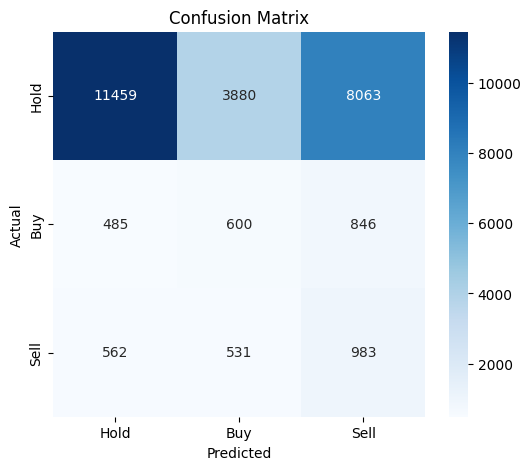


--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

        Hold       0.92      0.49      0.64     23402
         Buy       0.12      0.31      0.17      1931
        Sell       0.10      0.47      0.16      2076

    accuracy                           0.48     27409
   macro avg       0.38      0.42      0.33     27409
weighted avg       0.80      0.48      0.57     27409



In [36]:
# ---------------------------------------------------------
# 모델 평가 및 혼동 행렬 (Confusion Matrix)
# ---------------------------------------------------------

# 저장된 최고 성능 모델 불러오기
best_model = tf.keras.models.load_model('best_btc_bot_model.keras')

# 테스트 데이터 예측
print("\n--- 예측 수행 중... ---")
pred_probs = best_model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1) # 확률 -> 0, 1, 2 클래스로 변환
true_classes = np.argmax(y_test, axis=1)     # 정답 데이터

# 혼동 행렬 시각화
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hold', 'Buy', 'Sell'], 
            yticklabels=['Hold', 'Buy', 'Sell'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 상세 리포트 출력
print("\n--- 상세 분류 리포트 ---")
print(classification_report(true_classes, pred_classes, target_names=['Hold', 'Buy', 'Sell']))

In [37]:
# ---------------------------------------------------------
# 백테스팅 (Backtesting Simulation)
# ---------------------------------------------------------
# 간단한 로직: Buy 신호 시 전량 매수, Sell 신호 시 전량 매도
# ---------------------------------------------------------

initial_balance = 10000.0  # 초기 자본 $10,000
balance = initial_balance
position = 0               # 코인 보유량
fee_rate = 0.0004          # 수수료 0.04% (Binance Taker 기준)
portfolio_value = []       # 자산 가치 기록

# 테스트 데이터의 실제 가격 정보 가져오기 (전처리 전 df 사용 필요)
# 주의: test_df는 위 전처리 과정에서 정의된 원본 데이터 프레임이어야 함
test_close_prices = test_df['close'].values[TIME_STEPS:] # 시퀀스 길이만큼 앞부분 제외됨

print("\n--- 백테스팅 시작 (초기 자본: $10,000) ---")

for i in range(len(pred_classes)):
    action = pred_classes[i]
    current_price = test_close_prices[i]
    
    # 매수 (Buy) 신호
    if action == 1: 
        if balance > 0: # 현금이 있으면
            buy_amount = balance / current_price
            fee = balance * fee_rate
            position = buy_amount * (1 - fee_rate) # 수수료 차감 후 코인 보유
            balance = 0
            # print(f"매수: {current_price:.2f} USDT")

    # 매도 (Sell) 신호
    elif action == 2:
        if position > 0: # 코인이 있으면
            sell_amount = position * current_price
            fee = sell_amount * fee_rate
            balance = sell_amount - fee # 수수료 차감 후 현금 보유
            position = 0
            # print(f"매도: {current_price:.2f} USDT")
            
    # Hold는 아무것도 안함
    
    # 현재 총 자산 가치 기록
    current_val = balance + (position * current_price)
    portfolio_value.append(current_val)

# 최종 결과
final_balance = portfolio_value[-1]
roi = ((final_balance - initial_balance) / initial_balance) * 100

print(f"최종 자산: ${final_balance:.2f}")
print(f"수익률 (ROI): {roi:.2f}%")


--- 백테스팅 시작 (초기 자본: $10,000) ---
최종 자산: $8049.91
수익률 (ROI): -19.50%


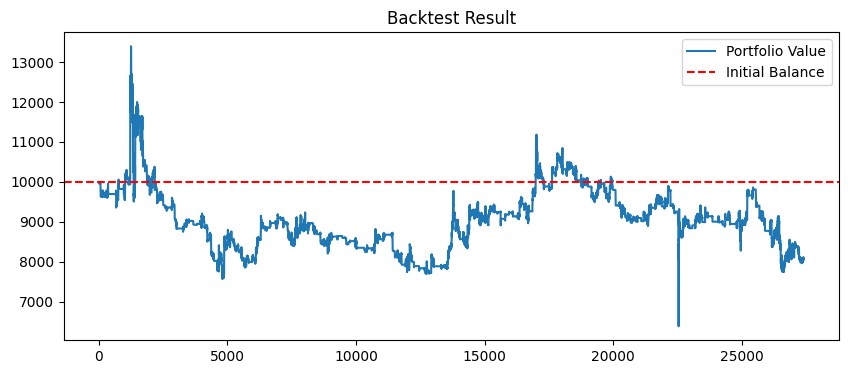

In [38]:
# 수익률 그래프
plt.figure(figsize=(10, 4))
plt.plot(portfolio_value, label='Portfolio Value')
plt.axhline(y=initial_balance, color='r', linestyle='--', label='Initial Balance')
plt.title('Backtest Result')
plt.legend()
plt.show()